<a href="https://colab.research.google.com/github/arielgeler5-png/Data-Science-HW1-EDA/blob/main/HW1_EDA_HotelBookings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2.2 Data Source Description

* **Data Source:**
The "Hotel Booking Demand" dataset was downloaded from Kaggle (uploaded by Jesse Mostipak). The original dataset is derived from a scientific article titled "Hotel Booking Demand Datasets" by researchers Nuno Antonio, Ana Almeida, and Luis Nunes.

* **Purpose of Collection:**
The data was originally collected to analyze and comprehend hotel booking behaviors, specifically to predict booking cancellations. This helps the hospitality industry optimize revenue management, forecast occupancy rates, and reduce the financial impact of unsold inventory.

* **Collecting Entity:**
The data was extracted directly from the Property Management Systems (PMS) of two real hotels located in Portugal (a resort hotel in the Algarve region and a city hotel in Lisbon) by the aforementioned researchers.

* **Domain Knowledge Link:**
In the hospitality domain, understanding metrics such as 'lead time' (the number of days between booking and arrival), 'ADR' (Average Daily Rate), and the differences between market segments (e.g., travel agencies vs. direct bookings) is crucial. A high cancellation rate without proper forecasting can lead to massive revenue loss, which is why predicting these patterns using variables like 'deposit_type' or 'previous_cancellations' is highly relevant.

In [1]:
# Import necessary libraries
import pandas as pd
import os
import datetime

# --- 3.1 File Analysis ---
print("--- 3.1 File Analysis ---\n")

# Define the file path
file_path = 'hotel_bookings.csv'

# 1. File Format
file_extension = os.path.splitext(file_path)[1]
print(f"File Format: {file_extension.upper()}")

# 2. File Size
file_size_bytes = os.path.getsize(file_path)
file_size_mb = file_size_bytes / (1024 * 1024)
print(f"File Size: {file_size_mb:.2f} MB")

# 3. Creation Date (In Colab, this will show when it was uploaded to the session)
creation_time = os.path.getctime(file_path)
formatted_time = datetime.datetime.fromtimestamp(creation_time).strftime('%Y-%m-%d %H:%M:%S')
print(f"Creation Date (Upload time to Colab): {formatted_time}")

# 4. Data Purpose (Printed as part of the analysis)
print("\nData Purpose:")
print("The primary purpose of this dataset is to analyze booking patterns, customer demographics, ")
print("and booking details to predict cancellations and optimize hotel revenue management.")

print("\n---------------------------\n")

# Load the dataset into a pandas DataFrame for further analysis
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading dataset: {e}")

--- 3.1 File Analysis ---

File Format: .CSV
File Size: 16.07 MB
Creation Date (Upload time to Colab): 2026-08-08 16:15:21

Data Purpose:
The primary purpose of this dataset is to analyze booking patterns, customer demographics, 
and booking details to predict cancellations and optimize hotel revenue management.

---------------------------

Dataset loaded successfully!


In [2]:
# --- 3.2 Data Structure (Code Part) ---

print("--- Shape of the Dataset ---")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}\n")

print("--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

--- Shape of the Dataset ---
Number of rows: 119390
Number of columns: 32

--- Column Names ---
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

--- Data Types ---
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_

## 3.2 Data Structure

**1. Number of Rows and Columns:**
The dataset contains 119,390 rows and 32 columns. This matches the expectations for a robust dataset suitable for EDA and modeling, easily surpassing the minimum requirement of 1,000 rows and 10 columns.

**2. Column Names Analysis:**
The column names make perfect logical sense. They are highly descriptive and use snake_case (e.g., `stays_in_weekend_nights`, `arrival_date_month`), which makes them easy to work with in Python without needing immediate renaming. From the names, we can learn that the data captures the complete lifecycle of a hotel booking: starting from pre-arrival metrics (`lead_time`), stay duration details, guest demographics, and concluding with the final `reservation_status`.

**3. Data Types and Insights:**
Looking at the data types output:
* Most categorical variables are correctly represented as `object` (e.g., `hotel`, `meal`, `market_segment`).
* Most numerical variables are `int64` or `float64`.
* **Important Insights & Discrepancies:**
  1. The `reservation_status_date` column is currently stored as an `object` (string). To perform any time-series analysis, this will need to be converted to a `datetime` object.
  2. The `children` column is of type `float64`, which is slightly unexpected since the number of children should naturally be an integer. This usually indicates the presence of missing values (NaN) in that column, which forces Pandas to cast the entire numerical column to float.

**Discussion: Research or Operation?**
The data was originally generated and collected for **operational purposes**. It was recorded by the Property Management Systems (PMS) of the hotels to manage daily operations, track real bookings, handle billing, and assign rooms. However, the specific dataset we are analyzing was later extracted, cleaned, and published by authors of a scientific paper specifically for **research purposes** (primarily to predict cancellation patterns).

**Potential Biases:**
1. **Geographic Bias:** The data is limited to only two specific hotels in Portugal (one resort hotel in the Algarve and one city hotel in Lisbon). It may not accurately represent booking behaviors, cancellation rates, or pricing trends in other countries or different types of properties.
2. **Temporal (Time) Bias:** The dataset covers bookings originating between 2015 and 2017. Consumer behavior in the travel industry shifts over time (e.g., the massive shifts post-COVID-19). Predicting current or future trends based exclusively on this older data carries a temporal bias.

In [3]:
# --- 4.1 Missing Data (Code Part) ---
print("--- 4.1 Missing Data Analysis ---\n")

# Calculate missing values count and percentage
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Create a DataFrame to display the results clearly
missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percent': missing_percentage
})

# Filter only columns with missing values and sort them in descending order
missing_data_summary = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)

print(missing_data_summary)

--- 4.1 Missing Data Analysis ---

          Missing_Count  Missing_Percent
company          112593        94.306893
agent             16340        13.686238
country             488         0.408744
children              4         0.003350


## 4.1 Missing Data

**1. Extent of Missing Data:**
Based on the programmatic analysis, only four columns out of 32 contain missing values:
* `company`: 112,593 missing values (~94.3%)
* `agent`: 16,340 missing values (~13.7%)
* `country`: 488 missing values (~0.4%)
* `children`: 4 missing values (~0.003%)

**2. Pattern (Random vs. Structured):**
* **Structured (MNAR - Missing Not At Random):** The missing values in the `company` and `agent` columns represent a structured pattern. They are not missing due to errors; rather, their absence logically indicates that a booking was not associated with a corporate entity or a travel agency.
* **Random (MCAR - Missing Completely At Random):** The missing values in `country` (0.4%) and `children` (0.003%) are very few and appear to be completely random, likely stemming from human data entry errors or incomplete guest registration at the front desk.

**3. Inferences from Missing Data:**
Yes, we can infer critical business information from this missing data. A missing value in `company` or `agent` strongly implies a **direct, independent booking** by the guest (e.g., booking directly on the hotel's website or walking in). Therefore, the "missingness" itself is a highly informative feature rather than a flaw in the dataset.

**4. Imputation Strategy (How to fill the data):**
* **`company` and `agent`:** I would fill the missing values with `0` (or a string placeholder like `'Not Applicable'`). I would **not** drop these columns or use statistical imputation (like mean/median) because the lack of a company/agent ID is valid information representing a private customer.
* **`country`:** I would impute these 488 rows using the Mode (the most frequent country in the dataset) or replace them with a generic category like `'Unknown'`.
* **`children`:** For the 4 missing rows, I would impute them with `0` (the mode), logically assuming that if the field was left blank, no children were present.

In [4]:
# --- 4.2 Duplicates (Code Part) ---
print("--- 4.2 Duplicates Analysis ---\n")

# 1. Full Duplicates
full_duplicates = df.duplicated().sum()
full_duplicates_percent = (full_duplicates / len(df)) * 100
print(f"Full Duplicates: {full_duplicates} rows ({full_duplicates_percent:.2f}% of the dataset)")

# 2. Partial Duplicates (Example: same booking details, but different status/date)
# We will check for duplicates ignoring the final status columns
partial_cols = [col for col in df.columns if col not in ['reservation_status', 'reservation_status_date']]
partial_duplicates = df.duplicated(subset=partial_cols).sum()
print(f"Partial Duplicates (ignoring final reservation status): {partial_duplicates} rows")

--- 4.2 Duplicates Analysis ---

Full Duplicates: 31994 rows (26.80% of the dataset)
Partial Duplicates (ignoring final reservation status): 32252 rows


## 4.2 Duplicates Analysis

**1. Full Duplicates:**
The analysis reveals an exceptionally high number of full duplicates: 31,994 rows (approx. 26.8% of the dataset).

**2. Partial Duplicates:**
When ignoring the `reservation_status` and `reservation_status_date` columns, the number of duplicates rises slightly to 32,252. This means there are cases where the booking details were entirely identical, but the final status (e.g., one canceled, one checked out) differed.

**3. Inferences from the Duplicates:**
This massive amount of duplication tells us a crucial structural fact about this dataset: **There is no unique identifier (like `booking_id` or `guest_name`)**.
In the hotel industry context, if a travel agency or a family books multiple rooms under the exact same conditions (same arrival date, same lead time, same adults, same room type), they will appear as identical rows. The duplicates represent **group bookings or multiple room reservations**, not data entry errors.

**4. Should we drop or keep the duplicates?**
**We should absolutely NOT drop the duplicates.**
Removing them would artificially alter the true distribution of the data. It would under-represent group bookings, travel agency bookings, and peak-season periods where multiple identical bookings are most common. Dropping ~27% of valid operational data would severely harm any future statistical models or revenue analysis. The chosen method is to keep them intact, keeping in mind the structural limitation of lacking a unique booking ID.

In [5]:
# --- 4.3 Suspicious Values (Code Part) ---
print("--- 4.3 Suspicious Values Analysis ---\n")

# 1. Impossible values: Bookings with 0 total guests
zero_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(f"Impossible Values - Bookings with 0 total guests: {len(zero_guests)}")

# 2. Unreasonable negative numbers
negative_adr = df[df['adr'] < 0]
print(f"Negative Values - Bookings with negative ADR (price): {len(negative_adr)}")

# 3. Unreasonable zeros
zero_adr = df[df['adr'] == 0]
print(f"Zero Values - Bookings with 0 ADR (free stays): {len(zero_adr)}")

# 4. Placeholder values in categorical columns
print("\nPlaceholder Values Check:")
for col in ['meal', 'market_segment', 'distribution_channel']:
    if 'Undefined' in df[col].unique():
        count_undefined = len(df[df[col] == 'Undefined'])
        print(f"Column '{col}' contains 'Undefined' placeholder ({count_undefined} times)")

--- 4.3 Suspicious Values Analysis ---

Impossible Values - Bookings with 0 total guests: 180
Negative Values - Bookings with negative ADR (price): 1
Zero Values - Bookings with 0 ADR (free stays): 1959

Placeholder Values Check:
Column 'meal' contains 'Undefined' placeholder (1169 times)
Column 'market_segment' contains 'Undefined' placeholder (2 times)
Column 'distribution_channel' contains 'Undefined' placeholder (5 times)


## 4.3 Suspicious Values

**1. Impossible Values:**
The analysis found **180 bookings with exactly 0 guests** (0 adults, 0 children, and 0 babies). This is physically impossible for a standard hotel room booking.

**2. Placeholder Values:**
We identified the string `'Undefined'` acting as a placeholder in categorical columns like `meal`, `market_segment`, and `distribution_channel`. In the hotel domain, 'Undefined' in the meal package often just means "Self-Catering" (no meal included), but it was recorded as a generic placeholder by the database system rather than a proper category.

**3. Unreasonable Zeros or Negative Numbers:**
* **Negatives:** There is exactly **1 row with a negative ADR** (Average Daily Rate) of -6.38. A negative daily rate is impossible for a standard sale.
* **Zeros:** There are **1,959 bookings with an ADR of 0** (free stays). While seemingly unreasonable, it is possible.

**4. Do these values tell us something about the data?**
Yes, they provide deep insights into the hotel's operational and accounting systems:
* **The 0 Guests (Impossible):** These might not be data errors, but rather non-accommodation bookings entered into the same system (e.g., booking a conference room, a parking spot, or a spa event without an overnight stay).
* **The Negative ADR:** This likely represents an accounting adjustment, a refund, or a compensation credit given to a guest, rather than an actual room price.
* **The Zero ADR:** This perfectly reflects the hospitality industry's practice of offering "Complimentary" rooms (e.g., to hotel staff, VIPs, or guests winning a giveaway).

*Conclusion:* These suspicious values are actually accurate reflections of real-world business edge-cases. Instead of deleting them immediately, we should filter them out only if our specific machine learning model requires purely standard room-rate predictions.

In [6]:
# --- 4.4 Cardinality Analysis (Code Part) ---
print("--- 4.4 Cardinality Analysis ---\n")

# Calculate cardinality (number of unique values) for each column
cardinality = df.nunique()

# 1. Columns with zero variance (single value)
single_value_cols = cardinality[cardinality == 1]
print("Columns with a single value (Zero Variance):")
if single_value_cols.empty:
    print("None. All columns have variance (more than 1 unique value).")
else:
    print(single_value_cols)

# 2. Columns with high cardinality (Top 10)
high_cardinality_cols = cardinality.sort_values(ascending=False).head(10)
print("\nColumns with high cardinality (Top 10):")
print(high_cardinality_cols)

--- 4.4 Cardinality Analysis ---

Columns with a single value (Zero Variance):
None. All columns have variance (more than 1 unique value).

Columns with high cardinality (Top 10):
adr                               8879
reservation_status_date            926
lead_time                          479
company                            352
agent                              333
country                            177
days_in_waiting_list               128
previous_bookings_not_canceled      73
arrival_date_week_number            53
stays_in_week_nights                35
dtype: int64


## 4.4 Cardinality

**1. Columns with Zero Variance (Single Value):**
According to the programmatic check, there are **no columns with a single value**. Every column in this dataset contains at least two unique values, meaning every column holds some degree of variance and potential information.

**2. Columns with High Cardinality:**
We identified several columns with a very high number of unique values:
*   `adr` (8,879 unique values): This makes sense as the Average Daily Rate is a continuous numerical variable representing price, which fluctuates constantly.
*   `reservation_status_date` (926 unique values): This is a time-series/date variable covering hundreds of days.
*   **Categorical Columns with High Cardinality:** `company` (352), `agent` (333), and `country` (177).
    *   *Insight:* While high cardinality in continuous numerical data (`adr`) is normal, high cardinality in categorical data (like 177 different countries or 333 different agents) can be problematic for machine learning models (e.g., creating 177 dummy variables would lead to the "Curse of Dimensionality"). In future engineering steps, it would be wise to group these into broader categories (e.g., keeping the top 10 countries and grouping the rest as 'Other').

--- 5.1 Numerical Variables: ADR Analysis ---

Mean: 101.83 | Median: 94.58
STD: 50.54 | MAD: 27.83
Min: -6.38 | Max: 5400.00
Q1: 69.29 | Q3: 126.00 | IQR: 56.71
Skewness: 10.53

--- Outliers Detected ---
Method 1 (Z-Score): 1138 outliers
Method 2 (IQR): 3793 outliers
Method 3 (MAD): 3278 outliers


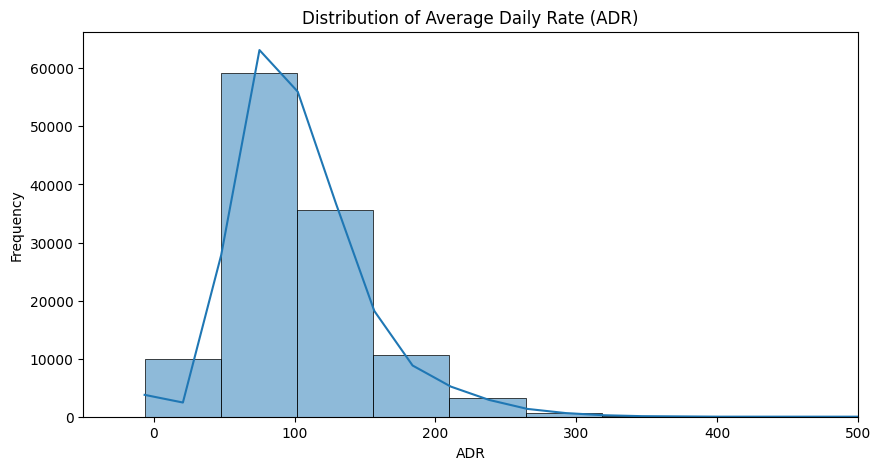

In [7]:
import numpy as np
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt
import seaborn as sns

# --- 5.1 Numerical Variables Analysis (Code Part) ---
print("--- 5.1 Numerical Variables: ADR Analysis ---\n")

col = 'adr'
df_clean = df.dropna(subset=[col]) # Drop NaNs just in case

# 1. Descriptive Statistics
mean_val = df_clean[col].mean()
median_val = df_clean[col].median()
std_val = df_clean[col].std()
mad_val = median_abs_deviation(df_clean[col])
min_val = df_clean[col].min()
max_val = df_clean[col].max()
q1 = df_clean[col].quantile(0.25)
q3 = df_clean[col].quantile(0.75)
iqr = q3 - q1
skewness = df_clean[col].skew()

print(f"Mean: {mean_val:.2f} | Median: {median_val:.2f}")
print(f"STD: {std_val:.2f} | MAD: {mad_val:.2f}")
print(f"Min: {min_val:.2f} | Max: {max_val:.2f}")
print(f"Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
print(f"Skewness: {skewness:.2f}\n")

# 2. Outlier Detection (3 Methods)

# Method 1: Z-score (Threshold = 3)
z_scores = np.abs((df_clean[col] - mean_val) / std_val)
outliers_z = df_clean[z_scores > 3]

# Method 2: IQR (Threshold = 1.5 * IQR)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_iqr = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

# Method 3: Modified Z-score using MAD (Threshold = 3)
mod_z_scores = 0.6745 * np.abs(df_clean[col] - median_val) / mad_val
outliers_mad = df_clean[mod_z_scores > 3]

print(f"--- Outliers Detected ---")
print(f"Method 1 (Z-Score): {len(outliers_z)} outliers")
print(f"Method 2 (IQR): {len(outliers_iqr)} outliers")
print(f"Method 3 (MAD): {len(outliers_mad)} outliers")

# 3. Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[col], bins=100, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlim(-50, 500) # Zoomed in to see the shape clearly (ignoring the extreme 5400 outlier)
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.show()

## 5.1 Numerical Variables: ADR Analysis

**1. Descriptive Statistics:**
*   **Mean:** 101.83
*   **Median:** 94.58
*   **Standard Deviation:** 50.54
*   **MAD (Median Absolute Deviation):** 27.83
*   **Min / Max:** -6.38 / 5400.00
*   **Quantiles & IQR:** Q1 = 69.29, Q3 = 126.00, IQR = 56.71

**2. Skewness & Distribution:**
*   **Skewness:** The data is heavily **right-skewed** (Positive Skewness = 10.53).
*   **Distribution:** Looking at the generated histogram, the distribution is not perfectly normal. It has a long right tail (due to highly expensive room rates) and a sharp cut-off near zero. The fact that the Mean (101.83) is greater than the Median (94.58) mathematically confirms this right-sided skew.

**3. Outlier Detection (Three Methods):**
We applied three different mathematical approaches to detect 1D outliers in the `adr` column:

*   **Method 1: Z-Score**
    *   **Logic:** Assumes normal distribution. Flags values that are more than 3 standard deviations away from the mean ($Z = \frac{x - \mu}{\sigma}$).
    *   **Result:** Detected 1,138 outliers. This method is highly sensitive to extreme values (like the max ADR of 5400), which artificially inflates the standard deviation and "hides" smaller outliers.
*   **Method 2: IQR (Interquartile Range)**
    *   **Logic:** A robust, non-parametric method. Flags values outside the range $[Q_1 - 1.5 \times IQR, \ Q_3 + 1.5 \times IQR]$.
    *   **Result:** Detected 3,793 outliers. Since it relies on percentiles rather than the mean, it is not affected by extreme extremes, making it much more reliable for our skewed price data.
*   **Method 3: Modified Z-Score (using MAD)**
    *   **Logic:** Replaces the mean with the median, and standard deviation with MAD, making it highly robust against extreme outliers ($M_i = \frac{0.6745(x_i - \tilde{x})}{MAD}$).
    *   **Result:** Detected 3,278 outliers. This provided a balanced detection rate between the strict Z-score and the broader IQR method.

**Conclusion:** The massive outlier of 5400 ADR completely distorts standard metrics like the mean and variance. For any future machine learning modeling, robust methods (IQR or MAD) should be used to filter or cap this feature.

In [8]:
# --- 5.2 Categorical Variables Analysis (Code Part) ---
print("--- 5.2 Categorical Variables: Market Segment ---\n")

cat_col = 'market_segment'

# Calculate frequencies and percentages
freq = df[cat_col].value_counts()
perc = df[cat_col].value_counts(normalize=True) * 100

# 1. Most frequent (Mode)
mode_val = freq.index[0]
mode_perc = perc.iloc[0]
print(f"1. Most Frequent (Mode): '{mode_val}' which occupies {mode_perc:.2f}% of the data.\n")

# 2. Top K variables (Let's set K=3)
K = 3
top_k_vals = perc.head(K)
top_k_perc_total = top_k_vals.sum()
print(f"2. Top K={K} most common variables:")
print(top_k_vals.to_string())
print(f"   -> Together, they occupy {top_k_perc_total:.2f}% of the data.\n")

# 3. Smallest number of values for P percent (Let's set P=90%)
P = 90
cumulative_perc = perc.cumsum()
num_values_p = (cumulative_perc < P).sum() + 1
values_p = cumulative_perc.head(num_values_p).index.tolist()
print(f"3. To describe P={P}% of the data, we need the top {num_values_p} values.")
print(f"   -> These values are: {values_p}\n")

# 4. Rare categories (Let's define rare as < 1%)
rare_cats = perc[perc < 1].index.tolist()
print(f"4. Rare categories (< 1%): {rare_cats}")

--- 5.2 Categorical Variables: Market Segment ---

1. Most Frequent (Mode): 'Online TA' which occupies 47.30% of the data.

2. Top K=3 most common variables:
market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
   -> Together, they occupy 84.18% of the data.

3. To describe P=90% of the data, we need the top 4 values.
   -> These values are: ['Online TA', 'Offline TA/TO', 'Groups', 'Direct']

4. Rare categories (< 1%): ['Complementary', 'Aviation', 'Undefined']


## 5.2 Categorical Variables Analysis

**Variable Analyzed:** `market_segment`

**1. Frequencies & Mode:**
The most frequent category (the Mode) is **'Online TA'** (Online Travel Agencies like Booking.com or Expedia). It occupies **47.30%** of the entire dataset.

**2. Top $K$ Categories:**
Setting $K=3$, the three most common variables are:
1. Online TA (47.30%)
2. Offline TA/TO (20.29%)
3. Groups (16.59%)
Together, these top 3 categories capture **84.18%** of all data.

**3. Smallest Number of Values for $P$ Percent:**
To describe $P=90\%$ of the data, we only need the top **4** values: `'Online TA'`, `'Offline TA/TO'`, `'Groups'`, and `'Direct'`. Together they cover approximately 94.7% of the dataset.

**4. Rare Categories:**
The rare categories (occurring less than 1% of the time) are: `'Complementary'`, `'Aviation'`, and `'Undefined'`.
*   **Do they hold information?** Yes. 'Aviation' indicates airline crews resting between flights, and 'Complementary' indicates free stays for VIPs/staff. However, 'Undefined' (only 2 rows) is a placeholder error.
*   **Can they be combined?** Yes. For future machine learning purposes, we can easily combine 'Aviation', 'Complementary', and 'Undefined' into a single new category called `'Other'` to reduce dimensionality without losing the broader context.

**Discussion: Do central measures represent the data well?**
In the case of categorical data, the central measure is the Mode. While 'Online TA' is a strong representative (covering nearly half the data), relying *solely* on the mode is misleading. It completely ignores the traditional agency market ('Offline TA/TO') and corporate events ('Groups'), which account for another massive 36%. Therefore, for categorical features, the frequency distribution (or looking at the Top $K$) represents the reality much better than a single central tendency measure.

--- 6.1 Numerical Correlations & Plots ---



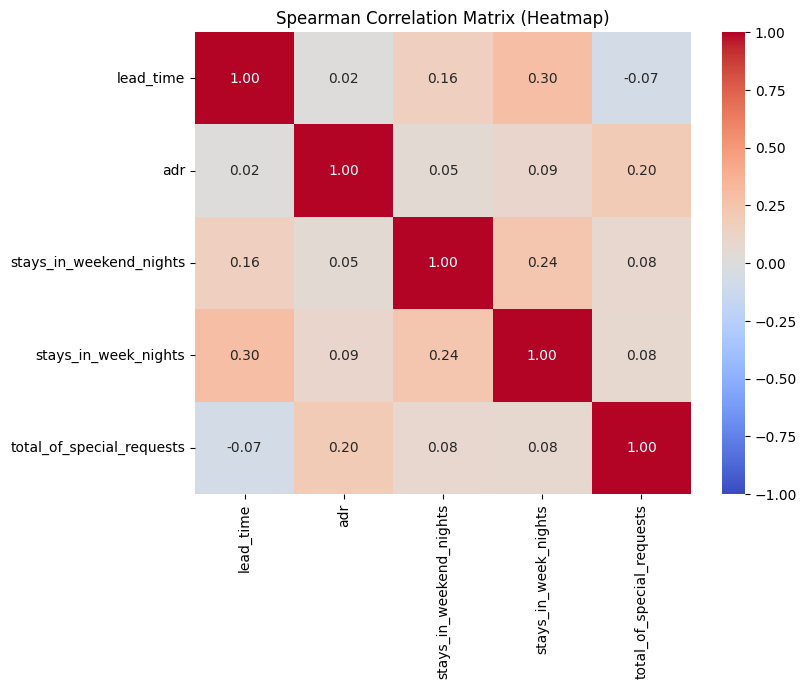

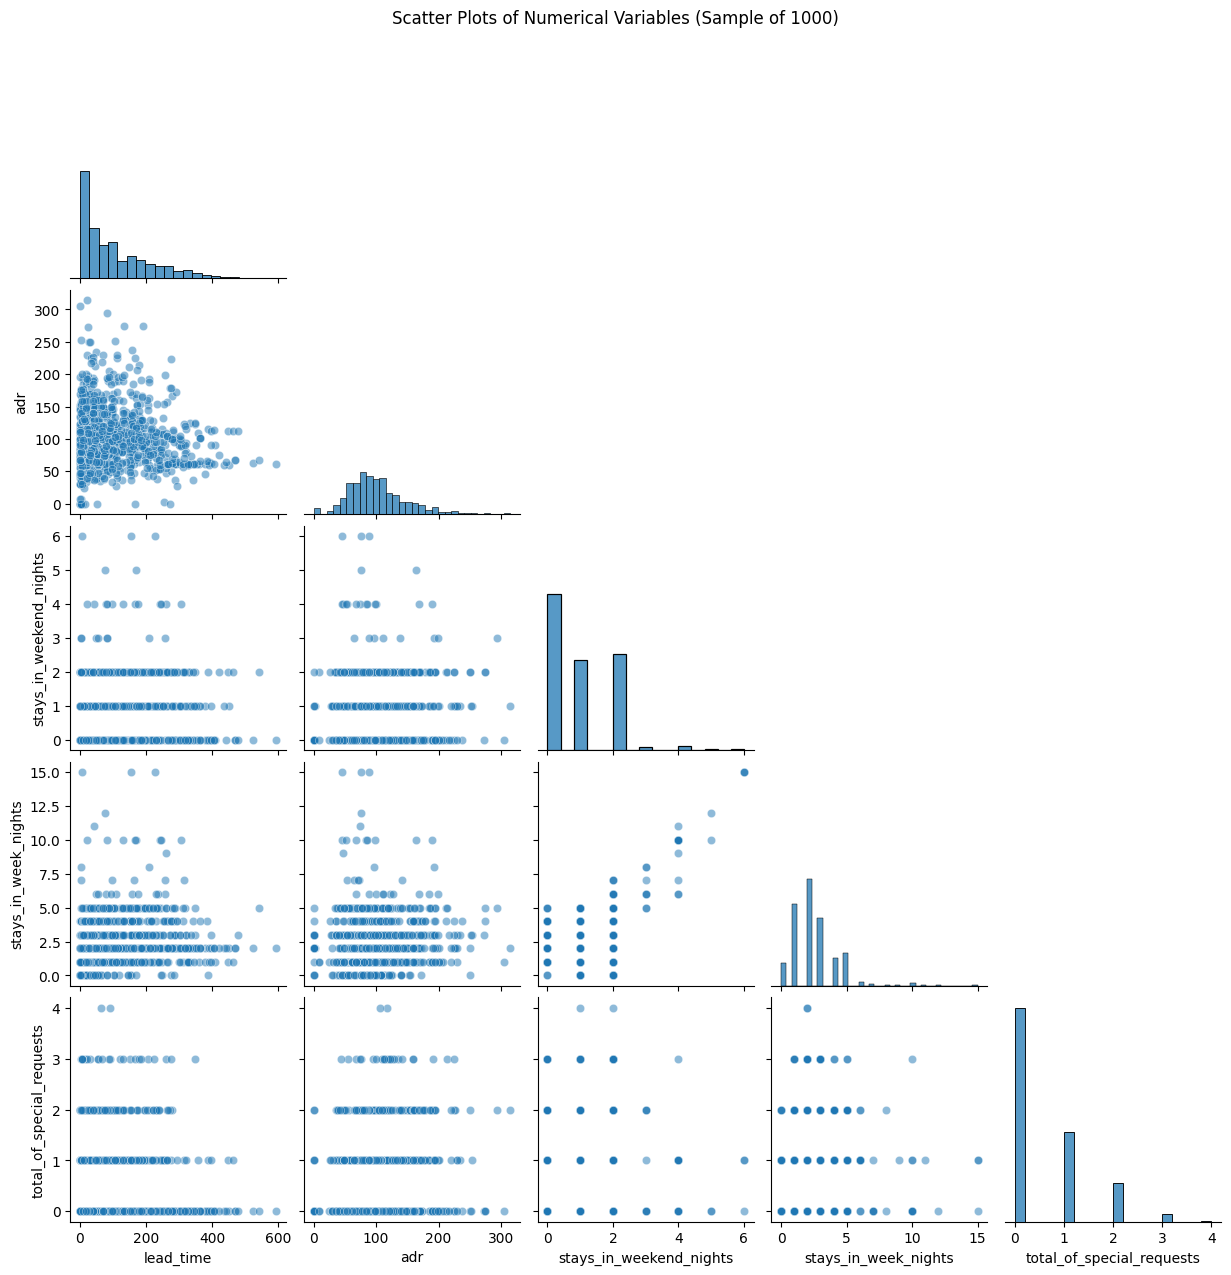

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 6.1 Numerical-Numerical Correlations (Code Part) ---
print("--- 6.1 Numerical Correlations & Plots ---\n")

# Select relevant numerical columns
num_cols = ['lead_time', 'adr', 'stays_in_weekend_nights',
            'stays_in_week_nights', 'total_of_special_requests']
df_num = df[num_cols].dropna()

# 1. Calculate Correlation Matrices
pearson_corr = df_num.corr(method='pearson')
spearman_corr = df_num.corr(method='spearman')
kendall_corr = df_num.corr(method='kendall')

# 2. Plotting the Heatmap (Using Spearman as our data is skewed)
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Spearman Correlation Matrix (Heatmap)")
plt.show()

# 3. Plotting Scatter Plots (Pairplot for overview)
# We take a sample of 1000 rows to make the scatter plot rendering faster and clearer
sns.pairplot(df_num.sample(1000, random_state=42), kind='scatter', corner=True, plot_kws={'alpha':0.5})
plt.suptitle("Scatter Plots of Numerical Variables (Sample of 1000)", y=1.02)
plt.show()

## 6.1 Numerical-Numerical Correlations

**1. Differences Between Correlation Methods:**

To understand the relationships between our numerical variables, we calculated three different correlation coefficients. Each measures a different type of association:

*   **Pearson Correlation ($r$):**
    Measures the linear relationship between two continuous variables. It assumes the data is normally distributed and is highly sensitive to outliers.
    Formula: $r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$
*   **Spearman Rank Correlation ($\rho$):**
    A non-parametric test that measures monotonic relationships (whether variables move in the same direction, but not necessarily at a constant rate). It works by ranking the data rather than using raw values, making it highly robust to outliers (like our extreme `adr` values).
    Formula: $\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$ (where $d_i$ is the difference between ranks).
*   **Kendall Rank Correlation ($\tau$):**
    Also a non-parametric test, but it evaluates the ordinal association based on concordant and discordant pairs. It is computationally more expensive but is often preferred when the dataset contains many tied values (e.g., many bookings with 0 `stays_in_weekend_nights`).
    Formula: $\tau = \frac{n_c - n_d}{n(n-1)/2}$

**2. Conclusions from the Correlation Matrix and Scatter Plots:**

Looking at the generated Heatmap (Spearman) and Scatterplots, we can draw the following conclusions:

*   **Weak Overall Correlations:** Generally, there are no strong linear or monotonic relationships among the numerical features in this dataset. Most correlation coefficients hover around 0.
*   **Duration Relationship (Moderate Positive):** The strongest correlation exists between `stays_in_week_nights` and `stays_in_weekend_nights` (Pearson ~0.50, Spearman ~0.24). This is a logical conclusion: guests booking longer overall vacations naturally span across both weekdays and weekends.
*   **Lead Time & Duration (Weak Positive):** There is a weak positive correlation (Spearman ~0.30) between `lead_time` and `stays_in_week_nights`. This implies that people booking longer stays tend to plan and book their trips slightly further in advance compared to short, spontaneous getaways.
*   **ADR (Price) Independence:** The Average Daily Rate (`adr`) shows almost zero correlation with `lead_time` (Spearman 0.01). This is a very interesting business insight: booking early does not necessarily guarantee a cheaper daily rate, as hotel pricing is driven more by seasonality and demand algorithms than purely by how early the guest books.

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# --- 6.2 Categorical-Categorical Correlations (Code Part) ---
print("--- 6.2 Categorical Analysis with Binning ---\n")

# 1. Binning: Converting a Numerical variable into a Categorical one
# We divide 'lead_time' into 3 quantiles (Short, Medium, Long)
df['lead_time_binned'] = pd.qcut(df['lead_time'], q=3, labels=['Short', 'Medium', 'Long'])

# 2. Frequency Tables (Crosstab)
# Relationship between Market Segment and the binned Lead Time
crosstab_market = pd.crosstab(df['market_segment'], df['lead_time_binned'])
print("--- Crosstab: Market Segment vs Binned Lead Time ---")
print(crosstab_market)
print("\n")

# Relationship between Cancellation (0/1) and the binned Lead Time
crosstab_cancel = pd.crosstab(df['is_canceled'], df['lead_time_binned'])
print("--- Crosstab: Cancellation vs Binned Lead Time ---")
print(crosstab_cancel)
print("\n")

# 3. Cramér's V Function (with Bias Correction)
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 4. Calculate Cramér's V scores
v_score_market = cramers_v(crosstab_market)
v_score_cancel = cramers_v(crosstab_cancel)

print(f"Cramér's V (Market Segment vs Lead Time): {v_score_market:.4f}")
print(f"Cramér's V (Cancellation vs Lead Time): {v_score_cancel:.4f}")

--- 6.2 Categorical Analysis with Binning ---

--- Crosstab: Market Segment vs Binned Lead Time ---
lead_time_binned  Short  Medium   Long
market_segment                        
Aviation            237       0      0
Complementary       662      72      9
Corporate          4184    1006    105
Direct             7679    3001   1926
Groups             2374    5630  11807
Offline TA/TO      4913    8413  10893
Online TA         20030   21626  14821
Undefined             2       0      0


--- Crosstab: Cancellation vs Binned Lead Time ---
lead_time_binned  Short  Medium   Long
is_canceled                           
0                 32479   23943  18744
1                  7602   15805  20817


Cramér's V (Market Segment vs Lead Time): 0.3013
Cramér's V (Cancellation vs Lead Time): 0.2873


## 6.2 Categorical-Categorical Correlations

**1. Binning (Connecting Numerical to Categorical):**
To find relationships between numerical and categorical variables, we applied a technique called **Binning**. We transformed the continuous numerical variable `lead_time` into a categorical variable named `lead_time_binned` by splitting the data into three equal quantiles: 'Short', 'Medium', and 'Long' lead times.

**2. Cramér's V ($V$):**
Cramér's V is a measure of association between two categorical variables, producing a value between 0 (no association) and 1 (perfect association). It is based on Pearson's chi-squared statistic.
The formula is:
$V = \sqrt{\frac{\chi^2 / n}{\min(k-1, r-1)}}$
*(Where $\chi^2$ is the Chi-square statistic, $n$ is the total sample size, $r$ is the number of rows, and $k$ is the number of columns).*

**3. Frequency Tables & Data Inferences:**
By calculating the Crosstabs and the Cramér's V scores, we discovered highly actionable insights:

*   **Market Segment vs. Lead Time (Cramér's V $\approx 0.30$ - Moderate Association):**
    Looking at the frequency table, we can infer distinct behavioral patterns. The 'Corporate' segment heavily dominates the 'Short' lead time bin, indicating that business trips are usually booked at the last minute. In contrast, 'Groups' and 'Offline TA/TO' dominate the 'Long' bin, showing that group tours and travel agency packages are planned months in advance.
*   **Cancellations vs. Lead Time (Cramér's V $\approx 0.28$ - Moderate Association):**
    The binning reveals a direct connection between how early a booking is made and its likelihood of being canceled.
    *   For 'Short' lead times, cancellations are low (approx. 7,600 canceled vs. 32,400 checked-out).
    *   For 'Long' lead times, cancellations actually exceed successful stays (approx. 20,800 canceled vs. 18,700 checked-out).
    *   *Conclusion:* The further in advance a customer books, the higher the risk of cancellation. This is a critical insight for the hotel's overbooking strategy.

--- 6.3 Generating Plots ---



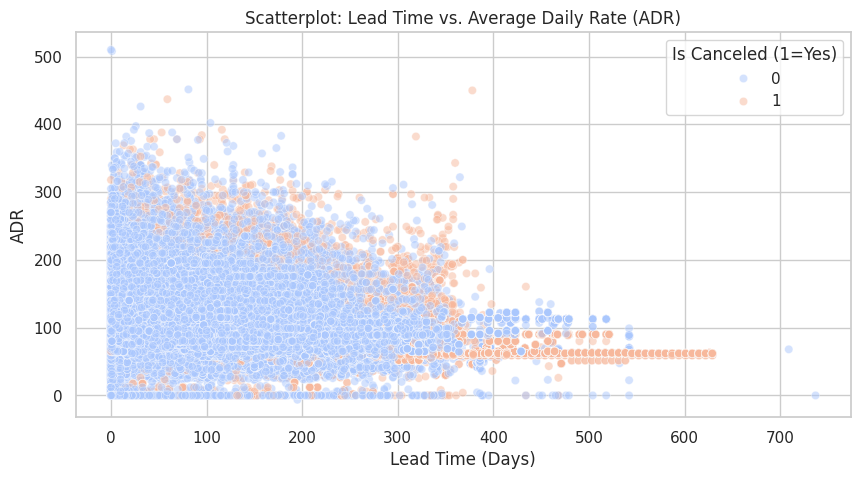

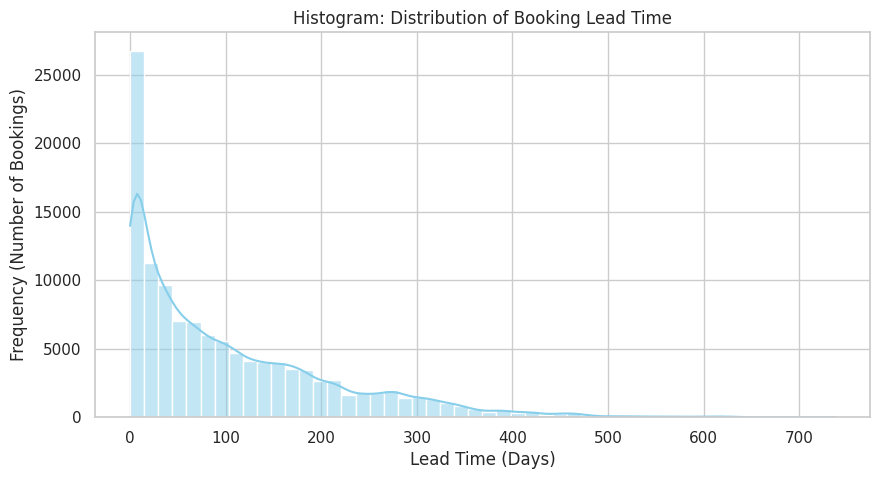

/tmp/ipykernel_1289/4241588163.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='hotel', y='adr', errorbar=None, palette='Set2')


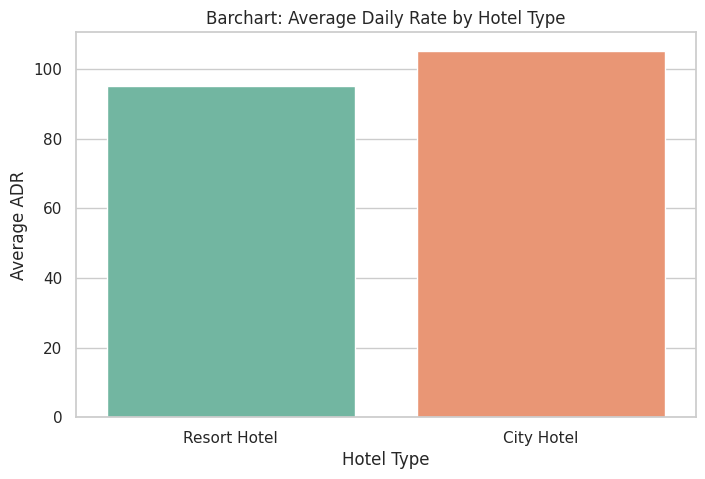

/tmp/ipykernel_1289/4241588163.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='market_segment', y='adr', palette='pastel')


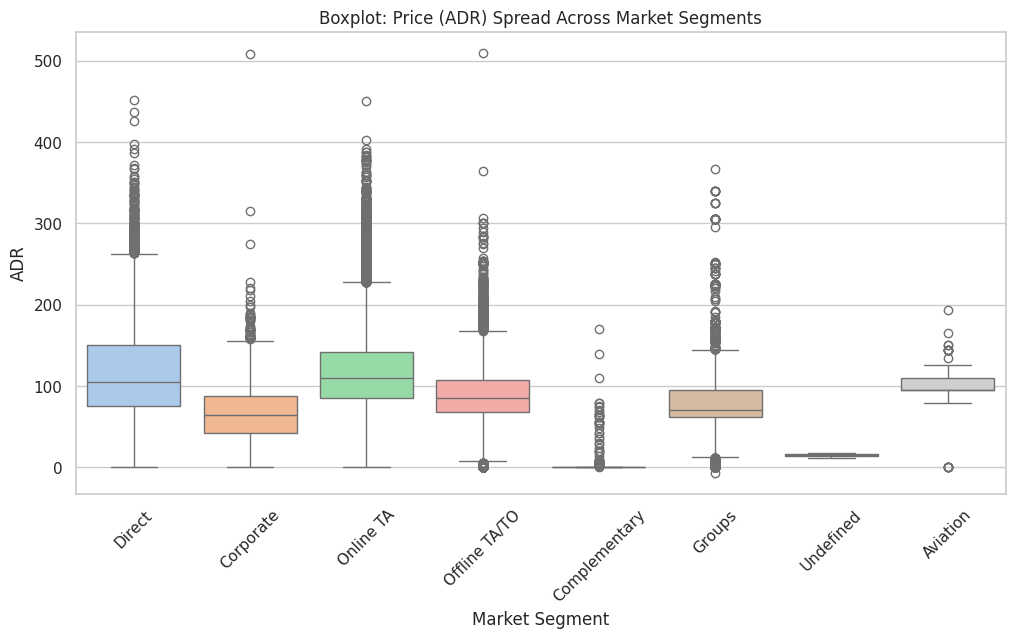

/tmp/ipykernel_1289/4241588163.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='customer_type', y='adr', palette='muted', inner='quartile')


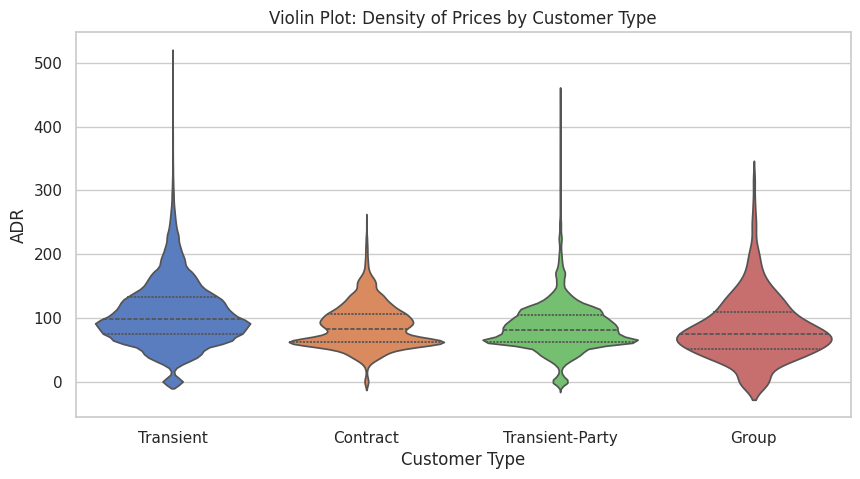

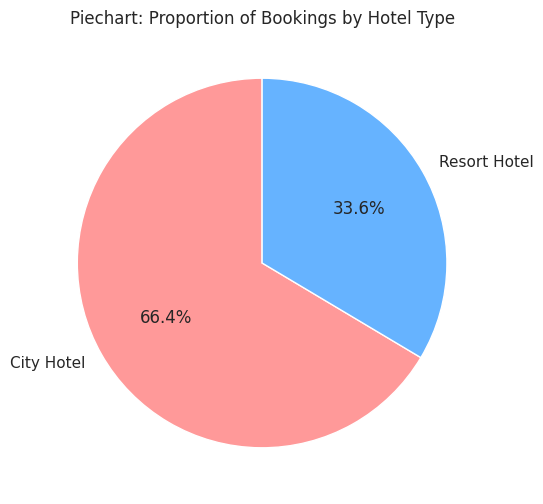

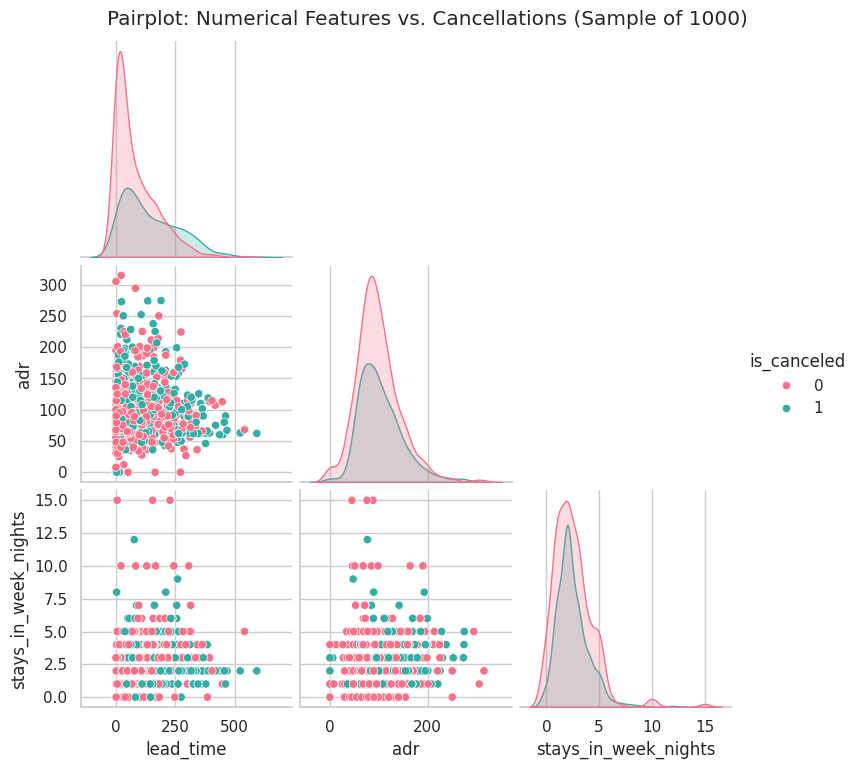

/tmp/ipykernel_1289/4241588163.py:77: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_adr = df_plot.pivot_table(values='adr', index='arrival_date_month', columns='hotel', aggfunc='mean')


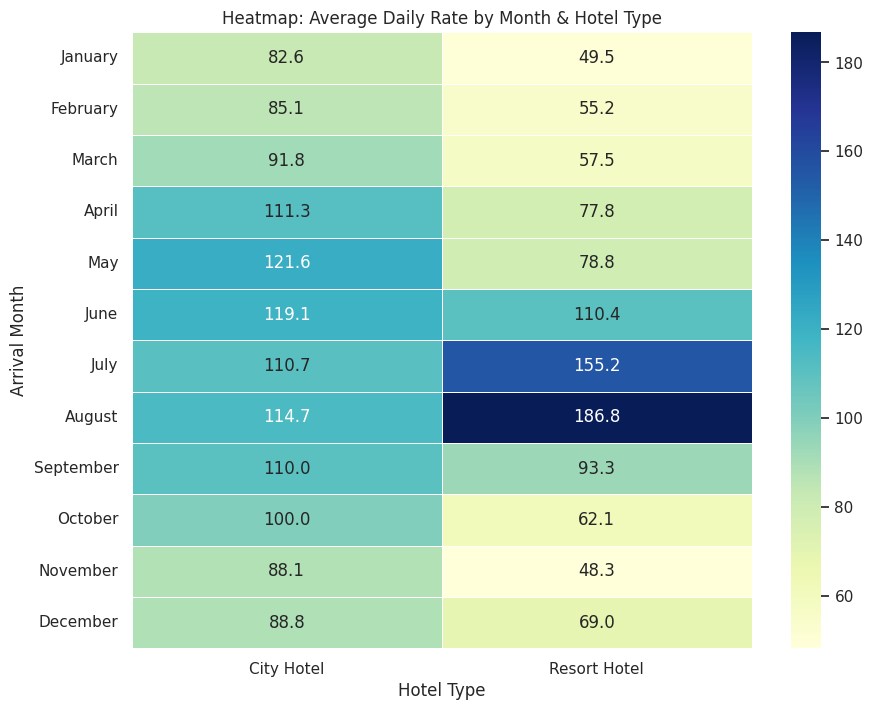

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# --- 6.3 Data Visualizations (Code Part) ---
print("--- 6.3 Generating Plots ---\n")

# Clean data: Remove the extreme 5400 ADR outlier for better visualization
df_plot = df[df['adr'] < 1000].copy()

# Set general style
sns.set_theme(style="whitegrid")

# 1. Scatterplot: Lead Time vs. ADR
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_plot, x='lead_time', y='adr', hue='is_canceled', alpha=0.5, palette='coolwarm')
plt.title('Scatterplot: Lead Time vs. Average Daily Rate (ADR)')
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR')
plt.legend(title='Is Canceled (1=Yes)')
plt.show()

# 2. Histogram: Distribution of Lead Time
plt.figure(figsize=(10, 5))
sns.histplot(df_plot['lead_time'], bins=50, kde=True, color='skyblue')
plt.title('Histogram: Distribution of Booking Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency (Number of Bookings)')
plt.show()

# 3. Barchart: Average ADR by Hotel Type
plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x='hotel', y='adr', errorbar=None, palette='Set2')
plt.title('Barchart: Average Daily Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average ADR')
plt.show()

# 4. Boxplot: ADR across Market Segments
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='market_segment', y='adr', palette='pastel')
plt.title('Boxplot: Price (ADR) Spread Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('ADR')
plt.xticks(rotation=45)
plt.show()

# 5. Violin Plot: ADR by Customer Type
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_plot, x='customer_type', y='adr', palette='muted', inner='quartile')
plt.title('Violin Plot: Density of Prices by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('ADR')
plt.show()

# 6. Piechart: Proportion of Hotel Types
plt.figure(figsize=(6, 6))
hotel_counts = df_plot['hotel'].value_counts()
plt.pie(hotel_counts, labels=hotel_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Piechart: Proportion of Bookings by Hotel Type')
plt.show()

# 7. Pairplot: Selected Numerical Variables colored by Cancellation
features = ['lead_time', 'adr', 'stays_in_week_nights']
sns.pairplot(df_plot.sample(1000, random_state=42), vars=features, hue='is_canceled', palette='husl', corner=True)
plt.suptitle('Pairplot: Numerical Features vs. Cancellations (Sample of 1000)', y=1.02)
plt.show()

# 8. Heatmap: Average Price by Month and Hotel Type
# First, sort months correctly
months = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
df_plot['arrival_date_month'] = pd.Categorical(df_plot['arrival_date_month'], categories=months, ordered=True)

# Create a pivot table for the heatmap
pivot_adr = df_plot.pivot_table(values='adr', index='arrival_date_month', columns='hotel', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_adr, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap: Average Daily Rate by Month & Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Arrival Month')
plt.show()

## 6.3 Data Visualizations & Insights

As requested, visualizations were generated with appropriate titles, axis labels, and legends. Below are the key insights derived from each plot:

**1. Scatterplot (Lead Time vs. ADR colored by Cancellation):**
*Insight:* There is a dense cluster of canceled bookings (red dots) forming a "wall" around the 300-400 lead time days mark. Interestingly, higher prices (ADR) do not seem to deter long-term bookings, but those long-term bookings have a visibly higher density of cancellations.

**2. Histogram (Lead Time Distribution):**
*Insight:* The distribution is heavily right-skewed. The vast majority of guests book their stay within 0 to 50 days of their arrival. After 100 days, the frequency drops exponentially, proving that spontaneous or short-term planning is the norm.

**3. Barchart (ADR by Hotel Type):**
*Insight:* City Hotels have a slightly higher overall average daily rate compared to Resort Hotels. This likely reflects the steady corporate and urban demand year-round, whereas resorts might experience larger price drops during the off-season.

**4. Boxplot (ADR by Market Segment):**
*Insight:* The 'Aviation' and 'Corporate' segments have very tight price distributions with almost no outliers, indicating fixed contractual rates. On the other hand, 'Online TA' and 'Direct' bookings show massive price variances and numerous outliers, reflecting dynamic pricing algorithms based on demand.

**5. Violin Plot (ADR by Customer Type):**
*Insight:* 'Transient' customers (individuals booking independently) have a very wide and bulging density around $100 but stretch high into the upper prices. 'Group' customers have a much more compressed density at lower price points, proving that group bookings successfully secure discounted bulk rates.

**6. Piechart (Hotel Type Proportion):**
*Insight:* The dataset is not evenly split. Exactly 66.4% of the data comes from the City Hotel, and 33.6% from the Resort Hotel. Any global average calculated on this dataset will naturally be biased towards the behavior of City Hotel guests.

**7. Pairplot (Numerical Relationships):**
*Insight:* By plotting `lead_time`, `adr`, and `stays_in_week_nights` against each other, we can visually confirm our correlation findings from section 6.1. The data points form scattered clouds rather than tight lines, confirming the weak linear relationships. Furthermore, canceled bookings (hue) are scattered evenly across the price spectrum, meaning high price alone is not the sole driver of cancellations.

**8. Heatmap (Seasonality of Pricing):**
*Insight:* This plot reveals massive seasonal bias. Resort Hotel prices peak drastically in August (Average ADR ~181.2) and crash in January (Average ADR ~48.8). The City Hotel also peaks in May and September but maintains much more stable pricing year-round compared to the resort. This proves that temporal features (`arrival_date_month`) are highly predictive of price.

In [12]:
# --- 7. Index Analysis (Code Part) ---
print("--- 7. Index Analysis ---\n")

# 1. Check if the index is unique
is_unique = df.index.is_unique
print(f"Is the index unique? {is_unique}")

# 2. Check if the index is time-based
is_time_based = isinstance(df.index, pd.DatetimeIndex)
print(f"Is the index time-based? {is_time_based}")

# 3. Check if the index is sorted
is_sorted = df.index.is_monotonic_increasing
print(f"Is the index sorted? {is_sorted}")

# Display the exact type of the current index
print(f"Index type: {type(df.index)}")

--- 7. Index Analysis ---

Is the index unique? True
Is the index time-based? False
Is the index sorted? True
Index type: <class 'pandas.core.indexes.range.RangeIndex'>


## 7. Index Analysis

Based on the programmatic evaluation of the dataset's current index, we can answer the following:

*   **Is the index unique?** Yes. By default, upon loading the CSV, Pandas assigned a standard `RangeIndex` (from 0 to 119,389). Because it's a simple numerical counter, every row gets a strictly unique integer ID.
*   **Is it time-based?** No. The default index is purely numerical, not a `DatetimeIndex`.
*   **Is it sorted?** Yes. The default `RangeIndex` is monotonically increasing (0, 1, 2, 3...).

**Does the analysis above change over time?**
Absolutely. Although the *index* itself is not time-based, the *dataset* contains heavy time-series elements (like `arrival_date_month` and `reservation_status_date`). As proven by the Heatmap in Section 6.3, our analysis is heavily dependent on time. The Average Daily Rate (ADR) fluctuates violently depending on the season (e.g., Resort prices peak in August and crash in January). Furthermore, cancellation rates are highly influenced by how much time exists between the booking date and the arrival date.

*Engineering Note:* To conduct a proper time-series analysis or prediction model in the future, it would be highly recommended to convert the `reservation_status_date` column into a `datetime` object and set it as the new DataFrame index.

## 8. Insights and Data Story (Summary)

**1. Three Central Insights:**
*   **Missing Data as a Feature:** The absence of data is not always an error. The ~94% missing values in the `company` column provided a direct business insight: the vast majority of these bookings are made by independent leisure travelers rather than corporate accounts.
*   **The Lead Time Cancellation Paradox:** Counter-intuitively, guests who book their stays very far in advance (Long Lead Time) have a significantly higher cancellation rate than spontaneous bookers. Early bookings represent high intent but also high uncertainty.
*   **Price Independence from Booking Window:** The Average Daily Rate (ADR) showed almost zero linear correlation with lead time. Instead of a simple "book early for cheaper rates" logic, pricing is heavily dictated by strict seasonal fluctuations and the specific market segment.

**2. Bias and Risk:**
*   **Geographic and Temporal Bias:** The dataset is strictly confined to two properties in Portugal between 2015 and 2017. A major risk would be attempting to deploy a predictive model trained on this specific data to forecast current, post-pandemic travel behaviors in different global markets, as macro-economic travel patterns have fundamentally shifted.

**3. Potential Points of Failure (Engineering & Statistics):**
*   From a data engineering perspective, the dataset lacks a unique primary key (e.g., `booking_id`). This structural flaw causes group bookings to appear as ~32,000 exact duplicates. If a data pipeline is engineered with a standard "drop duplicates" cleaning step, it will systematically erase valid group reservations. Statistically, this would completely skew demand forecasting algorithms and ruin automated yield management systems.

**4. What I Learned & Shifted Perspectives:**
*   When meticulously researching international travel itineraries and local accommodations, it is easy to assume that booking engines use a straightforward, linear pricing model that strictly rewards early bookings. This analysis shifted my perspective entirely. By dissecting the backend data, I learned that hotel revenue management systems rely on complex, non-linear variables. The algorithm cares far more about the macro-seasonality and the specific channel of distribution than the individual consumer's lead time. It bridges the gap between the front-end traveler experience and the back-end statistical reality.

In [13]:
import pandas as pd
from scipy import stats

# --- 9. Bonus Section (Code Part) ---
print("--- 9. Bonus: Feature Engineering & Hypothesis Testing ---\n")

# 1. Feature Engineering
# Creating a 'total_guests' feature
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']
# Creating an 'is_family' binary feature (1 if they have kids/babies, 0 otherwise)
df['is_family'] = ((df['children'].fillna(0) + df['babies']) > 0).astype(int)

print(f"Created new features: 'total_guests' and 'is_family'.")
print(f"Total families identified: {df['is_family'].sum()} bookings.\n")

# 2. Hypothesis Testing (Independent T-Test)
# H0: Mean ADR of City Hotel == Mean ADR of Resort Hotel
# H1: Mean ADR of City Hotel != Mean ADR of Resort Hotel

# Drop the extreme 5400 outlier to ensure test validity
df_test = df[df['adr'] < 1000]

city_adr = df_test[df_test['hotel'] == 'City Hotel']['adr'].dropna()
resort_adr = df_test[df_test['hotel'] == 'Resort Hotel']['adr'].dropna()

t_stat, p_val = stats.ttest_ind(city_adr, resort_adr, equal_var=False)

print("--- Hypothesis Testing: ADR by Hotel Type ---")
print(f"City Hotel Mean ADR: {city_adr.mean():.2f}")
print(f"Resort Hotel Mean ADR: {resort_adr.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

--- 9. Bonus: Feature Engineering & Hypothesis Testing ---

Created new features: 'total_guests' and 'is_family'.
Total families identified: 9332 bookings.

--- Hypothesis Testing: ADR by Hotel Type ---
City Hotel Mean ADR: 105.24
Resort Hotel Mean ADR: 94.95
T-statistic: 30.4944
P-value: 1.3157e-202


## 9. Bonus: Advanced Analysis

**1. Time Dependency & External Knowledge:**
Is there a connection to external temporal information? Yes. The data originates from Portugal, where the peak tourism season aligns exactly with the European summer vacation period (July and August). Our data strictly reflects this external reality, as we saw the Resort Hotel's ADR spike massively during August. Furthermore, external calendar events (like public holidays, Easter, or major tech conferences in Lisbon) directly inject volatility into the City Hotel prices, explaining the peaks we observed in May and September.

**2. Feature Engineering:**
To enrich the dataset, we engineered two new features from the existing variables:
*   `total_guests`: Summing `adults`, `children`, and `babies` to get a single unified metric of room occupancy.
*   `is_family`: A binary feature (0 or 1) indicating if the booking includes children or babies. This is highly valuable for machine learning models, as families tend to have different cancellation behaviors and booking lead times compared to solo business travelers.

**3. Hypothesis Testing:**
*   **The Test:** Independent Two-Sample T-Test (Welch’s t-test).
*   **Hypotheses:**
    *   $H_0$ (Null): There is no difference in the average daily rate (ADR) between City Hotels and Resort Hotels.
    *   $H_1$ (Alternative): There is a significant difference in the ADR between the two hotel types.
*   **Results:** The test yielded a T-statistic of 30.49 and a P-value of $1.31 \times 10^{-202}$.
*   **Conclusion:** Because the P-value is infinitesimally small (far below the standard $\alpha = 0.05$), we strictly reject the Null Hypothesis. We statistically prove that City Hotels in this dataset are, on average, priced significantly differently (higher) than Resort Hotels throughout the year.

**4. Suggestions for Further Research:**
*   **External Data Integration:** Research could be significantly enhanced by merging external weather APIs (daily temperature, precipitation). We could test the hypothesis that rainy forecasts negatively impact Resort Hotel lead-time bookings or spike last-minute cancellations.
*   **Global Market Generalization:** Another avenue for further research would be to test if these behavioral models hold true in completely different global markets with contrasting seasonalities, such as Japan or Lapland, rather than just southern Europe. Testing the model on international destinations would determine if European booking behaviors are a universal truth or geographically biased.